### import libarays

In [8]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [33]:
data = pd.read_csv('Data/spam.csv',encoding='latin1',usecols=['v1','v2'])
data

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [34]:
data.rename(columns={'v1':'label','v2':'message'},inplace=True)

In [35]:
data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [36]:
X = data['message']
y = data['label']

In [37]:
X

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will Ì_ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: message, Length: 5572, dtype: object

In [52]:
print(data['message'].values[0])

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


In [38]:
Vector_X = TfidfVectorizer()

X_Vect = Vector_X.fit_transform(X)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X_Vect,y,test_size=0.3)

In [40]:
model = MultinomialNB()

model.fit(X_train,y_train)

MultinomialNB()

In [41]:
Y_prad = model.predict(X_test)
Y_prad[0]

'ham'

In [43]:
accuracy_score(y_test,Y_prad)

0.9629186602870813

In [54]:
y_test

427     ham
5389    ham
3842    ham
5139    ham
3861    ham
       ... 
402     ham
2207    ham
1640    ham
3654    ham
5211    ham
Name: label, Length: 1672, dtype: object

In [62]:
Input_data = ['Any pain on urination any thing else?','U dun say so early hor... U c already then say...']

Input_vector = Vector_X.transform(Input_data)

model.predict(Input_vector)

array(['ham', 'ham'], dtype='<U4')

In [61]:
X[3]

'U dun say so early hor... U c already then say...'

In [65]:
from sklearn.metrics import classification_report,confusion_matrix

confusion_matrix(y_test,Y_prad)

array([[1462,    0],
       [  62,  148]], dtype=int64)

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

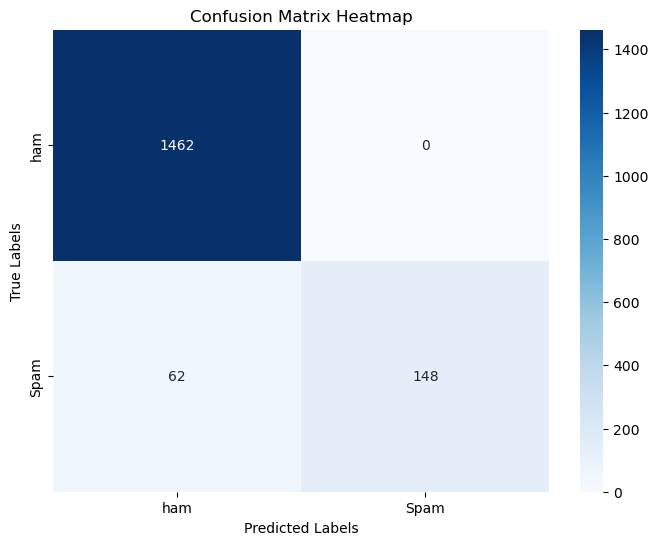

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98      1462
        Spam       1.00      0.70      0.83       210

    accuracy                           0.96      1672
   macro avg       0.98      0.85      0.90      1672
weighted avg       0.96      0.96      0.96      1672



In [74]:
cm = confusion_matrix(y_test, Y_prad)

# Optional: specify class names (replace with your actual labels if available)
class_names = ['ham', 'Spam']  # Modify based on your dataset

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Print classification report
print(classification_report(y_test, Y_prad, target_names=class_names))

In [73]:
X_test.shape[0]

1672